<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [42]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html
import unicodedata
import string

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
#Load dataset
df = pd.read_csv("train.csv")

In [3]:
#Explore basic info
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:", df.columns.tolist())

print("\n=== Data Types and Non-null Counts ===")
print(df.info())

print("\n=== First 5 rows ===")
print(df.head())

Number of rows: 27481
Number of columns: 4

Column names: ['textID', 'text', 'selected_text', 'sentiment']

=== Data Types and Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB
None

=== First 5 rows ===
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

         

**Спостереження**

Кількість записів: 27 481

Кількість колонок: 4

Назви полів: **['textID', 'text', 'selected_text', 'sentiment']**

Типи: усі object (тобто текстові)

Пропуски:

`text` — 1 пропуск

`selected_text` — 1 пропуск

`sentiment`, `textID` — без пропусків

In [4]:
# Drop rows with missing values
df = df.dropna().reset_index(drop=True)
print(f"\nAfter dropping missing values: {df.shape[0]} rows remain.")


After dropping missing values: 27480 rows remain.


In [5]:
#Verify again
print("\nMissing values after cleaning:")
print(df.isna().sum())


Missing values after cleaning:
textID           0
text             0
selected_text    0
sentiment        0
dtype: int64


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [9]:
# Distribution of target classes
sentiment_counts = df['sentiment'].value_counts()
sentiment_percent = df['sentiment'].value_counts(normalize=True) * 100

print("=== Distribution of Sentiment Classes ===")
print(sentiment_counts)
print("\n=== Percentage of Each Class ===")
print(sentiment_percent.round(2))

=== Distribution of Sentiment Classes ===
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64

=== Percentage of Each Class ===
sentiment
neutral     40.45
positive    31.23
negative    28.32
Name: proportion, dtype: float64


/tmp/ipython-input-3840587658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')


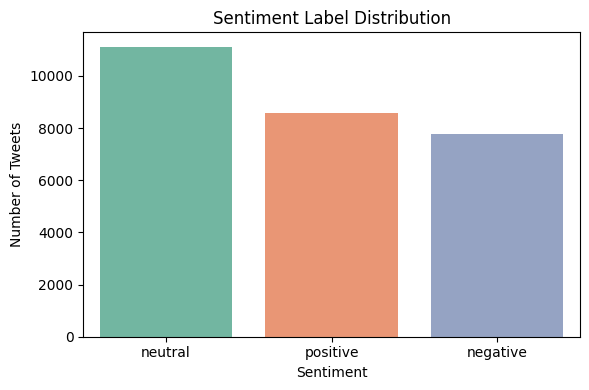

In [10]:
#Visualization
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()
plt.show()

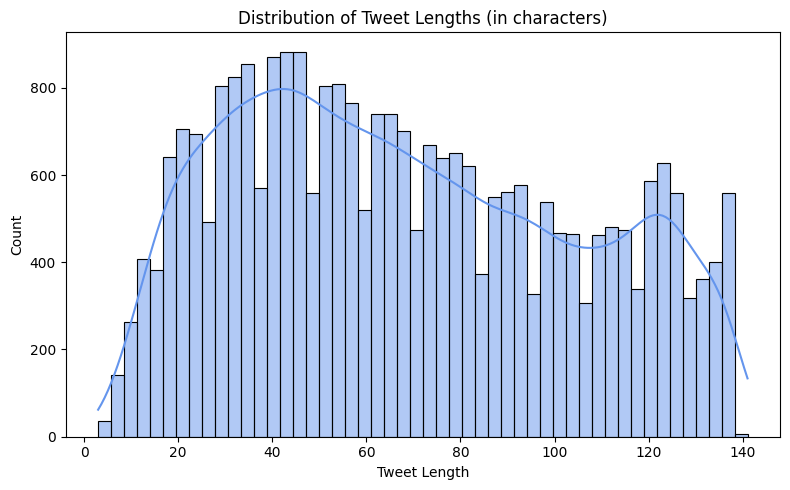

In [11]:
##Text length statistics
df['text_length'] = df['text'].astype(str).str.len()

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50, kde=True, color='cornflowerblue')
plt.title("Distribution of Tweet Lengths (in characters)")
plt.xlabel("Tweet Length")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [12]:
print("\n=== Tweet Length Statistics ===")
print(df['text_length'].describe())


=== Tweet Length Statistics ===
count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_length, dtype: float64


**Спостереження**

Ми бачимо, що:

- середня довжина твіта становить ≈68 символів

- 50% твітів коротші за 64 символи, а 75% - коротші за 97 символів

- мінімальна довжина - 3 символи, максимальна - 141 символ

**Висновок за розподілом довжин**

Якщо подивитися на гістограму, яку ми побудували раніше:

- розподіл асиметричний - більшість постів короткі, до 100 символів;

- пікове скупчення спостерігається у діапазоні 40-80 символів, тобто це 1-2 короткі речення;

- лише невелика частина твітів перевищує 120 символів.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [14]:
# NLTK stopwords + stemmer
try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem.snowball import SnowballStemmer
    _ = stopwords.words("english")
except Exception:
    import nltk
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    from nltk.stem.snowball import SnowballStemmer

EN_STOP = set(stopwords.words("english"))
STEM = SnowballStemmer("english")

In [16]:
# Regexes for tweet cleaning
_URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
_MENTION_RE = re.compile(r"@[A-Za-z0-9_]+")
_HASHTAG_RE = re.compile(r"#([A-Za-z0-9_]+)")
_HTML_TAG_RE = re.compile(r"<.*?>")
_MULTI_SPACE_RE = re.compile(r"\s+")
_KEEP_CHARS_RE = re.compile(r"[^a-z0-9'!? ]+")

def normalize_unicode(text: str) -> str:
    return unicodedata.normalize("NFKC", text)

def basic_clean(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text
    t = html.unescape(t)
    t = _HTML_TAG_RE.sub(" ", t)
    t = _URL_RE.sub(" URL ", t)
    t = _MENTION_RE.sub(" USER ", t)
    # replace #hashtag with its word
    t = _HASHTAG_RE.sub(r" \1 ", t)
    t = t.lower()
    # remove unwanted symbols (keep letters/digits/'/!/? and spaces)
    t = _KEEP_CHARS_RE.sub(" ", t)
    # collapse multi-spaces
    t = _MULTI_SPACE_RE.sub(" ", t).strip()
    t = normalize_unicode(t)
    return t

def tokenize_stem(text: str):
    """
    1) basic_clean
    2) split on whitespace (word-level tokens)
    3) remove stopwords and 1-char noise
    4) snowball stem
    """
    t = basic_clean(text)
    toks = t.split()
    out = []
    for tok in toks:
        # skip pure punctuation leftovers or very short tokens (except 'i')
        if len(tok) == 1 and tok not in {"i", "!", "?"}:
            continue
        if tok in EN_STOP:
            continue
        # strip leading/trailing apostrophes
        tok = tok.strip("'")
        if not tok:
            continue
        stem = STEM.stem(tok)
        out.append(stem)
    return out

In [17]:
# Decide vocabulary size (max_features)
MAX_FEATURES = 15000

bow_vectorizer = CountVectorizer(
    analyzer=tokenize_stem,    # custom tokenizer+stemmer
    lowercase=False,           # already lowered
    min_df=2,                  # drop ultra-rare noise
    max_df=0.95,               # drop extremely common tokens
    max_features=MAX_FEATURES  # control vocab size
)


In [18]:
# Fit-transform
X_bow = bow_vectorizer.fit_transform(df["text"].astype(str))
feature_names = np.array(bow_vectorizer.get_feature_names_out())

print("BoW shape:", X_bow.shape)  # (n_samples, vocab_size)
print("Sample features:", feature_names[:25])

BoW shape: (27480, 9262)
Sample features: ['!' '!!' '!!!' '!!!!' '!!!!!' '!!!!!!' '!!!!!!!!' '!!!!!!!!!'
 '!!!!!!!!!!!!' '!?' '00' '000' '007' '01' '03' '04' '05' '06' '07' '08'
 '09' '0981' '1!' '10' '100']


In [22]:
# Inspect top tokens by corpus frequency to optionally tweak MAX_FEATURES
token_freq = np.asarray(X_bow.sum(axis=0)).ravel()
top_idx = token_freq.argsort()[::-1][:30]
top_tokens = pd.DataFrame({
    "token": feature_names[top_idx],
    "freq": token_freq[top_idx]
})
print("\nTop 30 tokens by frequency (after cleaning+stemming)")
print(top_tokens.to_string(index=False))


Top 30 tokens by frequency (after cleaning+stemming)
 token  freq
    go  2320
   day  2131
   get  1912
  good  1517
  love  1457
  like  1454
  work  1452
   url  1324
   got  1095
   one  1034
  time  1029
 today  1019
 happi   991
  want   981
  miss   964
   lol   963
  know   920
   see   896
 thank   896
  back   877
realli   877
  feel   868
 think   863
    im   857
  hope   797
mother   784
  make   761
   new   741
 night   741
  look   722


In [25]:
# Сumulative coverage curve to guide max_features selection
sorted_freq = np.sort(token_freq)[::-1]
cum_freq = np.cumsum(sorted_freq)
coverage = cum_freq / cum_freq[-1] * 100
for c in [1000, 3000, 5000, 8000, 9262]:
    cov = coverage[min(c, len(coverage)) - 1]
    print(f"Top {c:>5} tokens cover ~{cov:5.2f}% of total counts")

Top  1000 tokens cover ~74.18% of total counts
Top  3000 tokens cover ~89.12% of total counts
Top  5000 tokens cover ~94.54% of total counts
Top  8000 tokens cover ~98.60% of total counts
Top  9262 tokens cover ~100.00% of total counts


### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [28]:
# Labels and split
y = df["sentiment"].values

X_train_bow, X_test_bow, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train_bow.shape, " Test size:", X_test_bow.shape)

Train size: (21984, 9262)  Test size: (5496, 9262)


In [29]:
# Define models
models = {
    "LogisticRegression": LogisticRegression(max_iter=300, solver="liblinear", class_weight="balanced", random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=30, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LinearSVC": LinearSVC(class_weight="balanced", random_state=42)
}

In [33]:
# Train and evaluate
results = []
for name, model in models.items():
  model.fit(X_train_bow, y_train)
  y_pred = model.predict(X_test_bow)
  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average="macro")
  results.append((name, acc, f1))
  print(f"\n=== {name} ===")
  print(f"Accuracy: {acc:.4f}, F1-macro: {f1:.4f}")
  print(classification_report(y_test, y_pred, digits=4))


=== LogisticRegression ===
Accuracy: 0.6885, F1-macro: 0.6908
              precision    recall  f1-score   support

    negative     0.6813    0.6594    0.6702      1556
     neutral     0.6470    0.6851    0.6655      2223
    positive     0.7549    0.7193    0.7367      1717

    accuracy                         0.6885      5496
   macro avg     0.6944    0.6879    0.6908      5496
weighted avg     0.6904    0.6885    0.6890      5496


=== DecisionTree ===
Accuracy: 0.6319, F1-macro: 0.6124
              precision    recall  f1-score   support

    negative     0.7628    0.3824    0.5094      1556
     neutral     0.5489    0.8507    0.6673      2223
    positive     0.7766    0.5748    0.6606      1717

    accuracy                         0.6319      5496
   macro avg     0.6961    0.6026    0.6124      5496
weighted avg     0.6806    0.6319    0.6205      5496


=== RandomForest ===
Accuracy: 0.6874, F1-macro: 0.6870
              precision    recall  f1-score   support

    ne

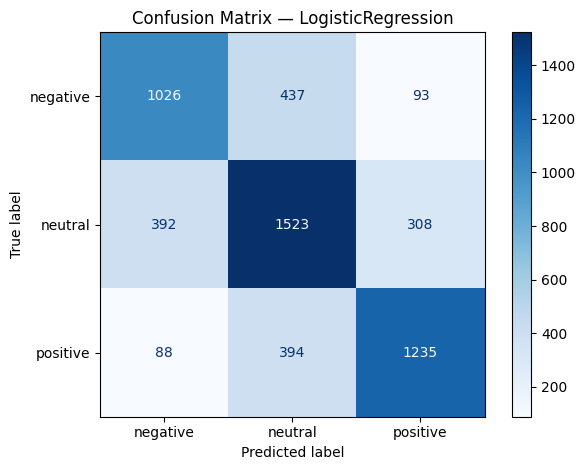

In [37]:
# Confusion matrix for the best model
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1_macro"]).sort_values("F1_macro", ascending=False)
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_bow)

cm = confusion_matrix(y_test, y_pred_best, labels=sorted(set(y_test)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(set(y_test)))
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


**Спостереження**

Найкраща модель Logistic Regression:

- F1-macro = 0.6885, Accuracy = 0.6908

- Найкраще розпізнає positive твіти (F1 ≈ 0.74), трохи гірше - neutral/negative, що типово для коротких текстів.

- Гарна збалансованість precision/recall - модель узагальнює добре.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [38]:
# Get feature_names & coefs
feature_names = np.array(bow_vectorizer.get_feature_names_out())
coefs = best_model.coef_
classes = best_model.classes_

top_tokens = {}

In [40]:
# Get top
for i, cls in enumerate(classes):
    coef = coefs[i]
    top_pos_idx = np.argsort(coef)[-15:][::-1]
    top_neg_idx = np.argsort(coef)[:15]

    top_tokens[cls] = {
        "top_positive": pd.DataFrame({
            "token": feature_names[top_pos_idx],
            "weight": coef[top_pos_idx]
        }),
        "top_negative": pd.DataFrame({
            "token": feature_names[top_neg_idx],
            "weight": coef[top_neg_idx]
        })
    }

for sentiment, data in top_tokens.items():
    print(f"\n {sentiment.upper()} sentiment ")
    print("Top indicative tokens (+):")
    print(data["top_positive"].to_string(index=False))
    print("\nMost opposite tokens (-):")
    print(data["top_negative"].to_string(index=False))


 NEGATIVE sentiment 
Top indicative tokens (+):
  token   weight
    sad 3.145391
 stupid 2.917415
   fail 2.833895
   hate 2.815078
   bore 2.746587
  worst 2.720622
   suck 2.705783
   wors 2.689272
    wtf 2.604750
  sorri 2.599855
   hurt 2.590460
   miss 2.525163
exhaust 2.518805
headach 2.505921
  weird 2.452716

Most opposite tokens (-):
   token    weight
    glad -2.955569
  awesom -2.695896
    love -2.628807
   thank -2.573689
  beauti -2.247485
awesome! -2.170174
  welcom -2.154588
    cute -2.111321
   enjoy -1.951949
    amaz -1.939548
    nice -1.845961
   great -1.788584
 thanks! -1.728683
   parvo -1.700864
    yay! -1.699177

 NEUTRAL sentiment 
Top indicative tokens (+):
      token   weight
      time? 1.834853
     indoor 1.814612
      parvo 1.770719
        jst 1.581378
   colorado 1.524013
        how 1.511699
    sarcast 1.495603
       chan 1.453057
starwarsday 1.438676
      2moro 1.415948
     guitar 1.378845
       why? 1.362543
    hummmmm 1.357666
   ass

**Загальний висновок**

Інтерпретація повністю логічна.
- Позитив - слова вдячності, радості, краси;
- негатив - лайливі, сумні, роздратовані;
- нейтрал - змішані або фактологічні.

Модель не "запам’ятала" випадкові токени, а справді виділила емоційно-значущі ознаки, що доводить її якість.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [44]:
# Labels and split
idx = np.arange(len(df))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)

X_train_text = df["text"].astype(str).iloc[idx_tr]
X_test_text  = df["text"].astype(str).iloc[idx_te]
y_train = y[idx_tr]
y_test  = y[idx_te]

In [45]:
# TF-IDF

tfidf = TfidfVectorizer(
    analyzer=tokenize_stem,
    lowercase=False,
    min_df=3,
    max_df=0.95,
    max_features=8000,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print("TF-IDF shapes:", X_train_tfidf.shape, X_test_tfidf.shape)

TF-IDF shapes: (21984, 5378) (5496, 5378)


In [46]:
# LogisticRegression
clf_tfidf = LogisticRegression(max_iter=300, solver="liblinear", class_weight="balanced", random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)

y_pred = clf_tfidf.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print("\nTF-IDF — LogisticRegression")
print(f"Accuracy: {acc:.4f}, F1-macro: {f1m:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))


TF-IDF — LogisticRegression
Accuracy: 0.6910, F1-macro: 0.6927

Classification report:
               precision    recall  f1-score   support

    negative     0.6907    0.6517    0.6706      1556
     neutral     0.6464    0.7031    0.6736      2223
    positive     0.7584    0.7111    0.7340      1717

    accuracy                         0.6910      5496
   macro avg     0.6985    0.6886    0.6927      5496
weighted avg     0.6939    0.6910    0.6916      5496



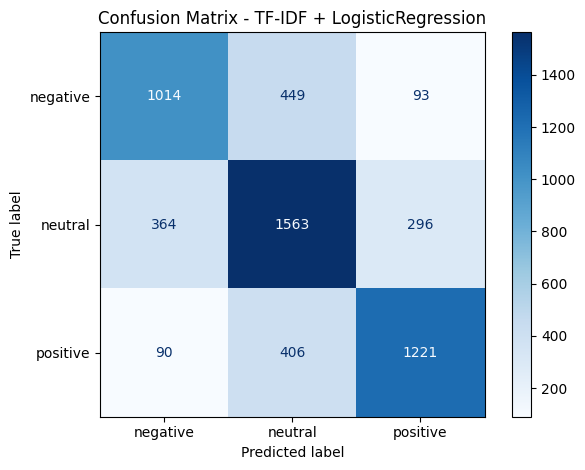

In [47]:
# Confusion Matrix - TF-IDF + LogisticRegression
labels_sorted = sorted(np.unique(y_test))
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - TF-IDF + LogisticRegression")
plt.tight_layout()
plt.show()

**Спостереження**

Різниця з BoW невелика (+0.002 F1-macro), але TF-IDF демонструє стабільніший баланс precision/recall, він приглушує вплив часто повторюваних слів і підсилює рідкісні, інформативні токени.

In [50]:
# Top TF-IDF + LogReg
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf_tfidf.coef_
classes = clf_tfidf.classes_

def top_table_for_class(i, k=15):
    w = coefs[i]
    top_pos = np.argsort(w)[-k:][::-1]
    top_neg = np.argsort(w)[:k]
    return (
        pd.DataFrame({"token": feature_names[top_pos], "weight": w[top_pos]}),
        pd.DataFrame({"token": feature_names[top_neg], "weight": w[top_neg]}),
    )

for i, cls in enumerate(classes):
    pos_tbl, neg_tbl = top_table_for_class(i, k=15)
    print(f"\n {cls.upper()} sentiment — TF-IDF weights ")
    print("Top indicative (+):")
    print(pos_tbl.to_string(index=False))
    print("\nMost opposite (-):")
    print(neg_tbl.to_string(index=False))


 NEGATIVE sentiment — TF-IDF weights 
Top indicative (+):
  token   weight
    sad 7.153561
   miss 6.358209
   hate 5.997976
  sorri 5.753862
   suck 5.178553
   fail 4.997042
   bore 4.878315
   hurt 4.833306
 stupid 4.810179
   sick 4.480207
   poor 4.478155
    bad 4.290967
headach 3.986672
   tire 3.812694
   feel 3.485141

Most opposite (-):
 token    weight
  love -6.742350
 thank -5.387943
awesom -4.017186
  hope -4.008192
  glad -3.930270
 great -3.698926
  nice -3.246703
 enjoy -3.070320
  amaz -2.927542
 happi -2.878807
  cute -2.679216
welcom -2.595411
better -2.557842
  good -2.400761
beauti -2.388385

 NEUTRAL sentiment — TF-IDF weights 
Top indicative (+):
 token   weight
guitar 1.559570
  why? 1.543961
 time? 1.513777
except 1.473257
differ 1.380605
  you? 1.370294
   tho 1.353898
indoor 1.353172
 there 1.333419
  list 1.291762
 updat 1.278672
   how 1.257557
  goin 1.218503
  sent 1.200278
   mmm 1.194987

Most opposite (-):
 token    weight
 happi -4.955759
  love -4

**Спостереження**

У BoW часті слова типу thank, love, good занадто сильні,а у TF-IDF ваги розподілились реалістичніше - модель стала більш "спокійною".

На мою думку, TF-IDF-векторизація - оптимальна для фінальної моделі LogisticRegression, тому що:

- покращує F1-macro,

- зменшує вплив "порожніх" слів,

- дає чистіші ваги й логічні токени.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [49]:
# Формуємо DataFrame із результатами
errors_df = pd.DataFrame({
    "text": X_test_text.values,
    "true": y_test,
    "pred": y_pred
})
errors_df["is_correct"] = (errors_df["true"] == errors_df["pred"])

# Лише помилки
misclassified = errors_df[~errors_df["is_correct"]]
print(f"Total misclassified: {len(misclassified)} ({len(misclassified)/len(errors_df)*100:.2f}%)")

# Найчастіше плутаються які класи?
conf_pairs = misclassified.groupby(["true", "pred"]).size().sort_values(ascending=False)
print("\nMost frequent confusion pairs")
print(conf_pairs.head(6))

# Подивимось приклади для кожного випадку
for (true_label, pred_label), _ in conf_pairs.head(3).items():
    print(f"\n--- True: {true_label} | Pred: {pred_label} ---")
    print(misclassified[(misclassified["true"] == true_label) & (misclassified["pred"] == pred_label)]["text"].head(5).to_list())

Total misclassified: 1698 (30.90%)

Most frequent confusion pairs
true      pred    
negative  neutral     449
positive  neutral     406
neutral   negative    364
          positive    296
negative  positive     93
positive  negative     90
dtype: int64

--- True: negative | Pred: neutral ---
['2 hours after teleconference. but can`t go back to sleep. got some work to do. sigh sigh', 'Youtube isn`t working...and I wanted to watch Britains Got Talent.  I`m debating about having a pity party.', ' aw. wasn`**** sad?! give ginger a little pat on the head for me!  mwah!', 'ahhhhh **** it..... none of my friends want to see it... and they don`t wanna chill tonight... so its just me myself and i', 'Im home where i am about 2 drink alone.']

--- True: positive | Pred: neutral ---
[' yum. Do you do home delivery', 'Having a wonderful piece of cake for lunch - what else could I want???', ' Don`t worry, you`ll get your stamina back soon  What kind of distances do you run usually?', '_Jamie I gues

**Спостереження**

Загальна кількість - 1698 помилкових прогнозів із 5496 (30.9%), модель має 69% accuracy. TF-IDF не розуміє сарказм, самотність, втому без ключових лексем, також модель не відчула позитиву без явних тригерів (love, great, awesome) та опис фізичного стану з нейтральним наміром, але є "hurt", "worse", "pain" - модель одразу віднесла до негативу.

**Шляхи покращення якості**

- Покращити репрезентацію тексту - додати біграми та триграми (ngram_range=(1,2) або (1,3)), щоб модель бачила фрази:
"can't wait", "not good", "so tired", "miss you", "love it".

- Додати емоційні та пунктуаційні фічі - ознаки емодзі, вигуків, знаків пунктуації:

"has_exclam", "has_qmark", "has_ellipsis", "num_exclam"

text.count('!'), text.count('?'), text.count('...')

- Використати словники настроїв (VADER, AFINN) - обчислити sentiment score й додати його як окрему фічу до моделі.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model